# Lesson 18: PWR Unit-Cell Design Studies

Lesson 17 measured one heterogeneous PWR cell. Here we parameterize the
same model and change one design variable at a time. The goal is to connect
pitch, H/U, soluble boron, fuel temperature, and moderator density to the
four factors.

## Controlled quantities

Unless a case explicitly says otherwise, we hold fixed

- fuel radius 0.45 cm and cladding outer radius 0.46 cm;
- 4 wt% U-235 enrichment and 10.5 g/cm$^3$ UO$_2$ density;
- 1200 K fuel and 600 K coolant at 15.5 MPa; and
- `c_H_in_H2O` thermal scattering data.

In [1]:
import os
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import openmc
import pandas as pd

cross_sections = os.environ.get("OPENMC_CROSS_SECTIONS")
if not cross_sections or not Path(cross_sections).is_file():
    raise RuntimeError(
        "Set OPENMC_CROSS_SECTIONS to an installed OpenMC "
        "continuous-energy cross_sections.xml file."
    )
openmc.config["cross_sections"] = cross_sections

REGION_NAMES = ("fuel", "cladding", "coolant")
GROUP_NAMES = ("T", "I", "F")
GROUP_EDGES = np.array([1.0e-5, 1.0, 1.0e5, 2.0e7])  # eV

FUEL_RADIUS = 0.45  # cm
CLAD_RADIUS = 0.46  # cm
FUEL_DIAMETER = 2.0 * FUEL_RADIUS
BASELINE_PITCH = 1.20  # cm
ENRICHMENT = 4.0       # weight percent
FUEL_TEMPERATURE = 1200.0  # K
MODERATOR_TEMPERATURE = 600.0  # K
MODERATOR_PRESSURE = 15.5  # MPa
BASELINE_BORON = 800.0  # ppm by weight
BASELINE_MODERATOR_DENSITY = (
    openmc.data.water_density(MODERATOR_TEMPERATURE, MODERATOR_PRESSURE)
    / (1.0 - BASELINE_BORON * 1.0e-6)
)

PURPLE = "#512888"
ORANGE = "#CA7C1B"
TEAL = "#008080"

## 1. Parameterize, run, and analyze one cell

`run_case` returns geometry metrics, the four retained-term factors,
$\zeta$, the exact factor cancellation, full-energy $B/A$, and
$k_\infty\pm\sigma_k$. Every OpenMC case runs in a temporary directory.


In [2]:
def build_pwr_model(
    *,
    pitch=BASELINE_PITCH,
    boron_ppm=BASELINE_BORON,
    fuel_temperature=FUEL_TEMPERATURE,
    moderator_temperature=MODERATOR_TEMPERATURE,
    moderator_density=BASELINE_MODERATOR_DENSITY,
    moderator_density_scale=1.0,
    particles=1200,
    batches=45,
    inactive=10,
    seed=18001,
):
    '''Return a reflected PWR model and its unit-height bookkeeping.'''
    if pitch <= 2.0 * CLAD_RADIUS:
        raise ValueError("pitch must exceed the cladding diameter")
    if moderator_density_scale <= 0.0:
        raise ValueError("moderator_density_scale must be positive")
    if moderator_density <= 0.0:
        raise ValueError("moderator_density must be positive")
    if not 0.0 <= boron_ppm < 1.0e6:
        raise ValueError("boron_ppm must be in [0, 1e6)")

    fuel = openmc.Material(name="UO2 fuel")
    fuel.add_element("U", 1.0, enrichment=ENRICHMENT)
    fuel.add_element("O", 2.0)
    fuel.set_density("g/cm3", 10.5)
    fuel.temperature = float(fuel_temperature)

    cladding = openmc.Material(name="zirconium cladding")
    cladding.add_element("Zr", 1.0)
    cladding.set_density("g/cm3", 6.6)
    cladding.temperature = 0.5 * (fuel_temperature + moderator_temperature)

    coolant = openmc.model.borated_water(
        boron_ppm=boron_ppm,
        temperature=moderator_temperature,
        temp_unit="K",
        # borated_water converts a water density to solution density.
        # This input makes the final solution density equal the
        # requested controlled value at every boron concentration.
        # The impact is probably very small.
        density=(
            moderator_density
            * moderator_density_scale
            * (1.0 - boron_ppm * 1.0e-6)
        ),
        name="borated light water",
    )
    # borated_water attaches c_H_in_H2O thermal scattering.
    coolant.temperature = float(moderator_temperature)

    fuel_surface = openmc.ZCylinder(r=FUEL_RADIUS)
    clad_surface = openmc.ZCylinder(r=CLAD_RADIUS)
    x_min = openmc.XPlane(x0=-pitch / 2.0, boundary_type="reflective")
    x_max = openmc.XPlane(x0=+pitch / 2.0, boundary_type="reflective")
    y_min = openmc.YPlane(y0=-pitch / 2.0, boundary_type="reflective")
    y_max = openmc.YPlane(y0=+pitch / 2.0, boundary_type="reflective")
    z_min = openmc.ZPlane(z0=-0.5, boundary_type="reflective")
    z_max = openmc.ZPlane(z0=+0.5, boundary_type="reflective")
    prism = +x_min & -x_max & +y_min & -y_max & +z_min & -z_max

    cells = (
        openmc.Cell(name="fuel", fill=fuel, region=-fuel_surface & prism),
        openmc.Cell(
            name="cladding",
            fill=cladding,
            region=+fuel_surface & -clad_surface & prism,
        ),
        openmc.Cell(name="coolant", fill=coolant, region=+clad_surface & prism),
    )
    volumes = np.array(
        [
            np.pi * FUEL_RADIUS**2,
            np.pi * (CLAD_RADIUS**2 - FUEL_RADIUS**2),
            pitch**2 - np.pi * CLAD_RADIUS**2,
        ]
    )
    for cell, volume in zip(cells, volumes, strict=True):
        cell.volume = float(volume)

    settings = openmc.Settings(run_mode="eigenvalue")
    settings.batches = int(batches)
    settings.inactive = int(inactive)
    settings.particles = int(particles)
    settings.seed = int(seed)
    settings.source = openmc.IndependentSource(
        space=openmc.stats.Point((0.0, 0.0, 0.0)),
        angle=openmc.stats.Isotropic(),
        energy=openmc.stats.Watt(),
    )
    settings.temperature = {"method": "interpolation"}

    rates = openmc.Tally(name="three-group rates")
    rates.filters = [openmc.CellFilter(cells), openmc.EnergyFilter(GROUP_EDGES)]
    rates.scores = ["flux", "absorption", "nu-fission"]

    model = openmc.Model(
        geometry=openmc.Geometry(cells),
        materials=openmc.Materials([fuel, cladding, coolant]),
        settings=settings,
        tallies=openmc.Tallies([rates]),
    )

    fuel_atoms = fuel.get_nuclide_atom_densities()
    coolant_atoms = coolant.get_nuclide_atom_densities()
    n_U = sum(value for name, value in fuel_atoms.items() if name.startswith("U"))
    n_H = sum(value for name, value in coolant_atoms.items() if name.startswith("H"))
    H_to_U = n_H * volumes[2] / (n_U * volumes[0])

    case = {
        "volumes": volumes,
        "pitch": pitch,
        "P/D": pitch / FUEL_DIAMETER,
        "Vm/Vf": volumes[2] / volumes[0],
        "H/U": H_to_U,
        "boron [ppm]": boron_ppm,
        "fuel temperature [K]": fuel_temperature,
        "moderator temperature [K]": moderator_temperature,
        "moderator density [g/cm3]": coolant.get_mass_density(),
    }
    return model, case


def run_case(**parameters):
    '''Run and reduce one case; factor ratios use mean tally values.'''
    model, case = build_pwr_model(**parameters)
    with tempfile.TemporaryDirectory(prefix="ne630_lesson18_") as run_dir:
        statepoint_path = model.run(cwd=run_dir, output=False)
        with openmc.StatePoint(statepoint_path) as statepoint:
            keff = statepoint.keff
            tally = statepoint.get_tally(name="three-group rates")
            flux = tally.get_values(
                scores=["flux"], value="mean"
            ).reshape(len(REGION_NAMES), len(GROUP_NAMES))
            absorption = tally.get_values(
                scores=["absorption"], value="mean"
            ).reshape(len(REGION_NAMES), len(GROUP_NAMES))
            production = tally.get_values(
                scores=["nu-fission"], value="mean"
            ).reshape(len(REGION_NAMES), len(GROUP_NAMES))

    T, I, F = range(3)
    FUEL, CLADDING, COOLANT = range(3)
    A_T = absorption[:, T].sum()
    A_I_fuel = absorption[FUEL, I]
    B_T = production[FUEL, T]
    B_F = production[FUEL, F]

    epsilon = (B_T + B_F) / B_T
    p = A_T / (A_T + A_I_fuel)
    f = absorption[FUEL, T] / A_T
    eta_T = B_T / absorption[FUEL, T]
    k_four = epsilon * p * f * eta_T
    k_retained = (B_T + B_F) / (A_T + A_I_fuel)
    np.testing.assert_allclose(k_four, k_retained, rtol=1.0e-12)

    phi_bar_T = flux[:, T] / case["volumes"]
    result = {
        **{key: value for key, value in case.items() if key != "volumes"},
        "epsilon": epsilon,
        "p": p,
        "f": f,
        "eta_T": eta_T,
        "zeta": phi_bar_T[COOLANT] / phi_bar_T[FUEL],
        "k_four": k_four,
        "B/A": production.sum() / absorption.sum(),
        "keff": float(keff.n),
        "sigma_k": float(keff.s),
    }
    return result


## 2. Hold fuel diameter fixed while changing pitch

For the square cell,

$$
\frac{V_m}{V_f}=\frac{P^2-\pi r_c^2}{\pi r_f^2},\qquad
\frac{H}{U}=\frac{N_H^m}{N_U^f}\frac{V_m}{V_f}.
$$

The isolated UO$_2$-rod correlation from Table 4.3 is

$$
I\,[\mathrm b]=4.45+26.6\sqrt{\frac{4}{\rho_fD}}.
$$

Because $D$ and $\rho_f$ remain fixed in this scan, the correlation gives
one constant reference value. It does **not** include inter-rod (Dancoff)
shielding, so it is an assumptions check rather than a substitute for the
transport result.


In [3]:
isolated_rod_I = 4.45 + 26.6 * np.sqrt(4.0 / (10.5 * FUEL_DIAMETER))
pd.Series(
    {
        "fuel diameter D [cm]": FUEL_DIAMETER,
        "fuel density rho_f [g/cm3]": 10.5,
        "isolated-rod resonance integral I [b]": isolated_rod_I,
        "baseline P/D": BASELINE_PITCH / FUEL_DIAMETER,
    },
    name="fixed fuel-rod quantities",
)


fuel diameter D [cm]                      0.900000
fuel density rho_f [g/cm3]               10.500000
isolated-rod resonance integral I [b]    21.755961
baseline P/D                              1.333333
Name: fixed fuel-rod quantities, dtype: float64

We scan ten $P/D$ values for unborated water and 800 ppm borated water.
The particle count is intentionally moderate for an instructional sweep;
use the reported $\sigma_k$ before declaring two neighboring points
distinguishable. A production study should increase histories and refine
the grid near the sampled maximum.


In [4]:
P_OVER_D_VALUES = np.linspace(1.10, 2.80, 10)
BORON_LEVELS = (0.0, BASELINE_BORON)

sweep_rows = []
for boron_index, boron_ppm in enumerate(BORON_LEVELS):
    for pitch_index, P_over_D in enumerate(P_OVER_D_VALUES):
        result = run_case(
            pitch=P_over_D * FUEL_DIAMETER,
            boron_ppm=boron_ppm,
            seed=18100 + 100 * boron_index + pitch_index,
        )
        sweep_rows.append(result)
        print(
            f"boron={boron_ppm:4.0f} ppm  P/D={P_over_D:.2f}  "
            f"keff={result['keff']:.5f} +/- {result['sigma_k']:.5f}"
        )

sweep = pd.DataFrame(sweep_rows).sort_values(["boron [ppm]", "P/D"])
sweep[
    [
        "boron [ppm]", "P/D", "Vm/Vf", "H/U", "keff", "sigma_k",
        "epsilon", "p", "f", "eta_T", "zeta", "k_four", "B/A",
    ]
]


boron=   0 ppm  P/D=1.10  keff=1.06217 +/- 0.00506


boron=   0 ppm  P/D=1.29  keff=1.25599 +/- 0.00499


boron=   0 ppm  P/D=1.48  keff=1.35964 +/- 0.00432


boron=   0 ppm  P/D=1.67  keff=1.42067 +/- 0.00482


boron=   0 ppm  P/D=1.86  keff=1.45094 +/- 0.00449


...

boron= 800 ppm  P/D=2.23  keff=1.23186 +/- 0.00426


boron= 800 ppm  P/D=2.42  keff=1.18872 +/- 0.00458


boron= 800 ppm  P/D=2.61  keff=1.12818 +/- 0.00445


boron= 800 ppm  P/D=2.80  keff=1.07735 +/- 0.00437


,boron [ppm],P/D,Vm/Vf,H/U,keff,sigma_k,epsilon,p,f,eta_T,zeta,k_four,B/A
0,0.0,1.100000,0.495682,0.935998,1.062168,0.005058,1.475960,0.283216,0.985925,1.848758,1.117988,0.761931,1.058672
1,0.0,1.288889,1.070211,2.020886,1.255994,0.004990,1.187489,0.496846,0.971544,1.859347,1.120917,1.065796,1.250867
2,0.0,1.477778,1.735597,3.277337,1.359641,0.004322,1.114098,0.620746,0.954804,1.864678,1.140041,1.231275,1.355248
3,0.0,1.666667,2.491838,4.705352,1.420667,0.004823,1.081039,0.707831,0.936142,1.867453,1.152780,1.337711,1.422834
4,0.0,1.855556,3.338936,6.304930,1.450945,0.004493,1.062248,0.763391,0.915436,1.869359,1.164833,1.387693,1.449559
5,0.0,2.044444,4.276889,8.076072,1.458913,0.005067,1.050248,0.810553,0.893079,1.870527,1.181276,1.422090,1.467541
6,0.0,2.233333,5.305698,10.018778,1.469316,0.004369,1.043187,0.838226,0.870195,1.871789,1.192988,1.424286,1.460112
7,0.0,2.422222,6.425362,12.133047,1.445709,0.003915,1.038224,0.861775,0.845464,1.872318,1.206107,1.416314,1.443526
8,0.0,2.611111,7.635883,14.418880,1.426335,0.004594,1.034099,0.883356,0.820557,1.872875,1.213634,1.403831,1.423124
9,0.0,2.800000,8.937260,16.876276,1.399139,0.004928,1.030595,0.900131,0.796161,1.873332,1.216495,1.383596,1.399686


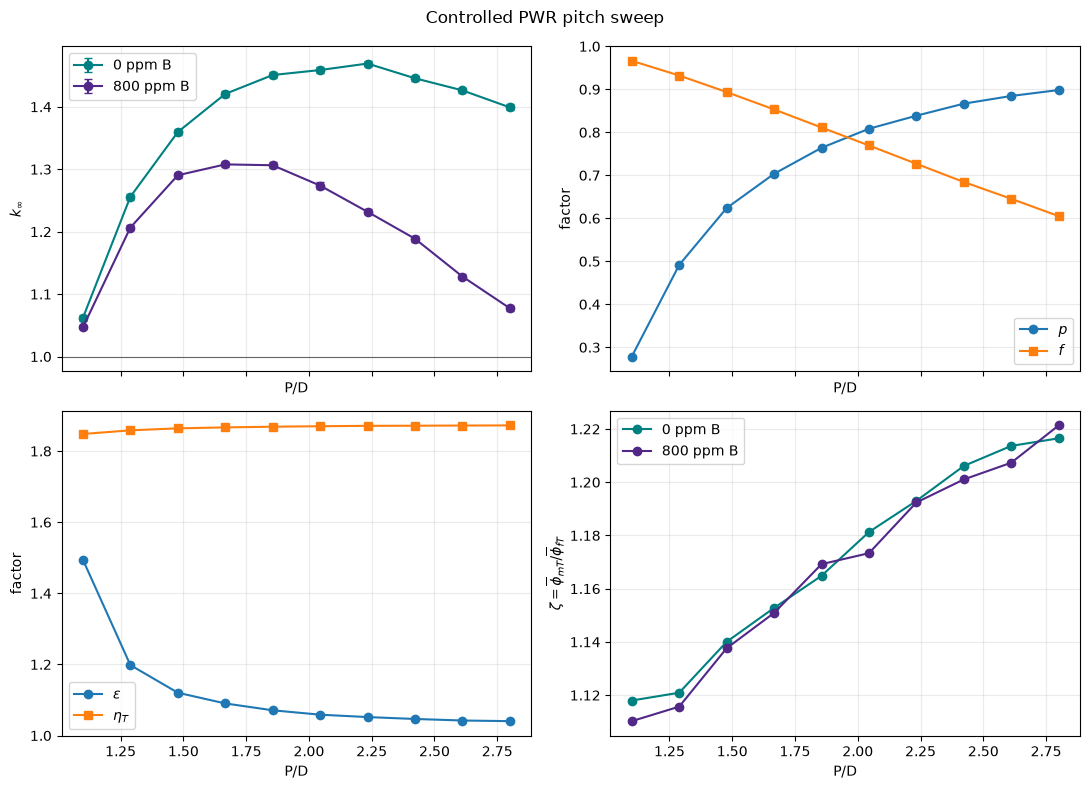

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)

for boron_ppm, color in zip(BORON_LEVELS, (TEAL, PURPLE), strict=True):
    subset = sweep[sweep["boron [ppm]"] == boron_ppm]
    label = f"{boron_ppm:.0f} ppm B"
    axes[0, 0].errorbar(
        subset["P/D"], subset["keff"], yerr=subset["sigma_k"],
        marker="o", capsize=3, color=color, label=label,
    )
    axes[1, 1].plot(
        subset["P/D"], subset["zeta"], marker="o", color=color, label=label
    )

reference = sweep[sweep["boron [ppm]"] == BASELINE_BORON]
axes[0, 1].plot(reference["P/D"], reference["p"], "o-", label="$p$")
axes[0, 1].plot(reference["P/D"], reference["f"], "s-", label="$f$")
axes[1, 0].plot(
    reference["P/D"], reference["epsilon"], "o-", label=r"$\epsilon$"
)
axes[1, 0].plot(
    reference["P/D"], reference["eta_T"], "s-", label=r"$\eta_T$"
)

axes[0, 0].axhline(1.0, color="0.4", linewidth=0.8)
axes[0, 0].set_ylabel(r"$k_\infty$")
axes[0, 1].set_ylabel("factor")
axes[1, 0].set_ylabel("factor")
axes[1, 1].set_ylabel(r"$\zeta=\overline{\phi}_{mT}/\overline{\phi}_{fT}$")
for ax in axes.ravel():
    ax.set_xlabel("P/D")
    ax.grid(alpha=0.25)
    ax.legend()
fig.suptitle("Controlled PWR pitch sweep")
fig.tight_layout();


In [6]:
sampled_optima = (
    sweep.loc[sweep.groupby("boron [ppm]")["keff"].idxmax()]
    [["boron [ppm]", "P/D", "H/U", "keff", "sigma_k", "p", "f"]]
    .set_index("boron [ppm]")
)
sampled_optima


,P/D,H/U,keff,sigma_k,p,f
boron [ppm],,,,,,
0.0,2.233333,10.018778,1.469316,0.004369,0.838226,0.870195
800.0,1.666667,4.701587,1.307780,0.004197,0.703502,0.853219


More moderator generally raises $p$ by reducing resonance losses, while it
lowers $f$ by increasing nonfuel thermal absorption. Their competition
produces the sampled maximum. Soluble boron acts primarily through $f$,
but transport recouples the spectrum and all four factors.

A point on the low-moderator side of the maximum is **undermoderated**:
lowering moderator density from that point tends to lower multiplication.
Error bars and grid spacing matter when deciding which side of the maximum
a case occupies.


## 3. Separate boron, Doppler, and density changes

At the original 1.20 cm pitch, the following independent cases change only
one named input from the 800 ppm baseline. The moderator-density case keeps
temperature (and therefore the thermal-scattering temperature) fixed while
scaling number density by 0.90. This is a controlled diagnostic, not a full
thermohydraulic state.


In [7]:
perturbations = (
    ("baseline", {}),
    ("remove soluble boron", {"boron_ppm": 0.0}),
    ("fuel 1500 K", {"fuel_temperature": 1500.0}),
    ("moderator density x 0.90", {"moderator_density_scale": 0.90}),
)

perturbation_rows = []
for index, (label, changes) in enumerate(perturbations):
    parameters = {
        "pitch": BASELINE_PITCH,
        "boron_ppm": BASELINE_BORON,
        "seed": 18500 + index,
    }
    parameters.update(changes)
    result = run_case(**parameters)
    result["case"] = label
    perturbation_rows.append(result)
    print(
        f"{label:27s}  keff={result['keff']:.5f} "
        f"+/- {result['sigma_k']:.5f}"
    )

perturbations_table = pd.DataFrame(perturbation_rows).set_index("case")
rho = 1.0 - 1.0 / perturbations_table["keff"]
perturbations_table["delta rho [pcm]"] = 1.0e5 * (rho - rho.iloc[0])
perturbations_table[
    [
        "boron [ppm]", "fuel temperature [K]", "moderator density [g/cm3]",
        "keff", "sigma_k", "delta rho [pcm]", "epsilon", "p", "f",
        "eta_T", "zeta", "B/A",
    ]
]


baseline                     keff=1.22384 +/- 0.00391


remove soluble boron         keff=1.28616 +/- 0.00510


fuel 1500 K                  keff=1.22461 +/- 0.00472


moderator density x 0.90     keff=1.21240 +/- 0.00421


,boron [ppm],fuel temperature [K],moderator density [g/cm3],keff,sigma_k,delta rho [pcm],epsilon,p,f,eta_T,zeta,B/A
case,,,,,,,,,,,,
baseline,800.0,1200.0,0.661649,1.223837,0.003911,0.000000,1.175466,0.524774,0.922524,1.859843,1.129707,1.228449
remove soluble boron,0.0,1200.0,0.661649,1.286156,0.005102,3959.201726,1.164512,0.527473,0.967678,1.860590,1.124451,1.275942
fuel 1500 K,800.0,1500.0,0.661649,1.224606,0.004721,51.324413,1.179587,0.520286,0.922798,1.859396,1.127854,1.219048
moderator density x 0.90,800.0,1200.0,0.595484,1.212400,0.004209,-770.788638,1.197081,0.495382,0.929501,1.858694,1.130310,1.205768


## Interpretation and limits

1. Removing boron should chiefly increase thermal utilization $f$.
2. Raising fuel temperature broadens U-238 resonances and usually lowers
   $p$ in this thermal lattice (the Doppler contribution).
3. Lowering moderator density changes both resonance escape and thermal
   utilization. Its sign depends on which side of the lattice maximum the
   baseline occupies.
4. Independent Monte Carlo cases have independent uncertainties; do not
   over-interpret a change comparable with the combined statistical error.
